# 11 - Pipeline `srm-noise` (Optuna-tuned)

Fixed SRM high-pass + learnable Bayar constrained-conv noise residual -> compact CNN. The search tunes the CNN width, Bayar channels, optimizer and loss.

**Sections:** 0 Setup - 1 Data - 2 Hyperparameter search (Optuna) - 3 Final train - 4 Curves - 5 In-dist eval - 6 OOD preview - 7 Explainability - 8 metrics.json

Training is **Optuna-driven**: a search maximizes val AUC (with pruning), the winner is saved, and the final model is trained on it. Set `TUNE=False` to skip the search and reuse the committed `best_params.json`. Artifacts -> `notebooks/artifacts/srm-noise/{models,figures,metrics,tuning}`.

## 0 - Setup

In [1]:
import sys, time, json, gc
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display
import optuna

_here = Path.cwd()
_nb_dir = _here if (_here / "utils").is_dir() else _here / "notebooks"
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

from utils import datasets as D, models as M, training as T, metrics as Me, viz as V, explain as E, eda, tuning as TU
from utils.paths import repo_paths, artifact_dirs

optuna.logging.set_verbosity(optuna.logging.WARNING)
torch.manual_seed(42); np.random.seed(42)
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PATHS = repo_paths(_nb_dir)
DATA_DIR = PATHS["data"]
AIR_DIR = DATA_DIR / "ai-real-images"
SPLIT_PATH = AIR_DIR / "manifest_split.csv"
TINY_MANIFEST = DATA_DIR / "tiny-genimage" / "manifest_clean.csv"

PIPELINE = "srm-noise"
WORKING_SIZE = 128
NORM = "dataset"
BATCH_SIZE = 128
TUNE = True
N_TRIALS = 24
SEARCH_EPOCHS = 10
FINAL_EPOCHS = 40
WARMUP_EPOCHS = 2
NUM_WORKERS = 8
dirs = artifact_dirs(PIPELINE)
print("device:", device, "| pipeline:", PIPELINE)

device: cuda | pipeline: srm-noise


## (GPU clean)

In [2]:
# Clear the GPU at the very start (frees this process's CUDA cache + reports free VRAM).
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache(); torch.cuda.ipc_collect()
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU cleaned - free {free_b / 1e9:.1f} / {total_b / 1e9:.1f} GB")
else:
    print("CPU mode - nothing to clean")

GPU cleaned - free 11.8 / 12.9 GB


## 1 - Data

In [3]:
loaders = D.make_loaders(SPLIT_PATH, working_size=WORKING_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, norm=NORM)
train_loader, val_loader, test_loader = loaders["train"], loaders["val"], loaders["test"]
mean, std = D.resolve_stats(NORM, AIR_DIR)
split_df = pd.read_csv(SPLIT_PATH); split_df = split_df[split_df["keep"]]
test_df = split_df[split_df["split_final"] == "test"].reset_index(drop=True)
print(f"train {len(train_loader.dataset):,} | val {len(val_loader.dataset):,} | test {len(test_loader.dataset):,}")

train 43,127 | val 4,792 | test 11,963


## 2 - Hyperparameter search (Optuna)

In [4]:
SEARCH_SPACE = {
    "feat": {"type": "categorical", "choices": [128, 256, 384]},
    "bayar_ch": {"type": "categorical", "choices": [3, 6]},
    "p_drop": {"type": "float", "low": 0.1, "high": 0.5},
    "lr": {"type": "loguniform", "low": 1e-3, "high": 3e-3},
    "weight_decay": {"type": "loguniform", "low": 5e-4, "high": 2e-3},
    "label_smooth": {"type": "float", "low": 0.0, "high": 0.1},
    "loss": {"type": "categorical", "choices": ["bce", "focal"]},
}
DEFAULTS = {"feat": 256, "bayar_ch": 3, "p_drop": 0.3, "lr": 1.5e-3, "weight_decay": 1e-3, "label_smooth": 0.05, "loss": "bce"}

def objective(trial):
    p = {
        "feat": trial.suggest_categorical("feat", [128, 256, 384]),
        "bayar_ch": trial.suggest_categorical("bayar_ch", [3, 6]),
        "p_drop": trial.suggest_float("p_drop", 0.1, 0.5),
        "lr": trial.suggest_float("lr", 1e-3, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 5e-4, 2e-3, log=True),
        "label_smooth": trial.suggest_float("label_smooth", 0.0, 0.1),
        "loss": trial.suggest_categorical("loss", ["bce", "focal"]),
    }
    gamma = trial.suggest_float("focal_gamma", 1.0, 3.0) if p["loss"] == "focal" else 2.0
    model = M.build_srm_cnn(feat=p["feat"], bayar_ch=p["bayar_ch"], p_drop=p["p_drop"]).to(device, memory_format=torch.channels_last)
    try:
        return TU.quick_train_eval(model, train_loader, val_loader, device, lr=p["lr"], weight_decay=p["weight_decay"],
                                   epochs=SEARCH_EPOCHS, trial=trial, loss_fn=TU.make_loss(p["loss"], gamma), label_smooth=p["label_smooth"])
    finally:
        TU.cleanup(model)

def _cb(study, trial):
    v = trial.value if trial.value is not None else float("nan")
    print(f"  trial {trial.number:02d}: {trial.state.name:8s} value={v:.4f}")

TUNE_SUMMARY = {"tuned": bool(TUNE), "search_space": SEARCH_SPACE}
if TUNE:
    study = TU.make_study(PIPELINE, dirs["models"].parent / "tuning")
    study.optimize(objective, n_trials=N_TRIALS, callbacks=[_cb], gc_after_trial=True)
    TU.save_study_artifacts(study, SEARCH_SPACE, dirs["figures"], dirs["metrics"])
    best = {**DEFAULTS, **study.best_params}
    TUNE_SUMMARY.update(n_trials=len(study.trials), best_val_auc=float(study.best_value), best_params=best)
    print("\nBEST:", best, "| val_auc", round(study.best_value, 4))
else:
    best = TU.load_best_params(dirs["metrics"], DEFAULTS)
    TUNE_SUMMARY["best_params"] = best
    print("TUNE off -> using", best)

  trial 00: COMPLETE value=0.9239


  trial 01: COMPLETE value=0.9292


  trial 02: COMPLETE value=0.9189


  trial 03: COMPLETE value=0.9203


  trial 04: COMPLETE value=0.9210


...

  trial 22: PRUNED   value=0.9088


  trial 23: PRUNED   value=0.8911


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)


C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\utils\tuning.py:143: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  ax = fn(study)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\optuna\visualization\matplotlib\_parallel_coordinate.py:115: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(dim.range[0], dim.range[1])



BEST: {'feat': 128, 'bayar_ch': 6, 'p_drop': 0.345207821056262, 'lr': 0.0013737630283266352, 'weight_decay': 0.0010237589162286939, 'label_smooth': 0.025061205134484225, 'loss': 'bce'} | val_auc 0.9324


## 3 - Final train (best params)

In [5]:
model = M.build_srm_cnn(feat=best["feat"], bayar_ch=best["bayar_ch"], p_drop=best["p_drop"]).to(device, memory_format=torch.channels_last)
print("params:", f"{M.count_params(model):,}")
loss_fn = TU.make_loss(best["loss"], best.get("focal_gamma", 2.0))
optimizer = torch.optim.AdamW(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
spe = len(train_loader); scheduler = T.build_cosine_with_warmup(optimizer, total_steps=FINAL_EPOCHS * spe, warmup_steps=WARMUP_EPOCHS * spe)
stopper = T.EarlyStopper(mode="max", patience=7, min_delta=1e-3)
history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_acc": []}
best_auc = -1.0; ckpt_path = dirs["models"] / "best.pt"
for epoch in range(FINAL_EPOCHS):
    t0 = time.time()
    tr = T.train_one_epoch(model, train_loader, optimizer, loss_fn, device, scheduler=scheduler, label_smooth=best["label_smooth"])
    yv, pv, vloss = T.evaluate(model, val_loader, device, loss_fn); vm = Me.classification_metrics(yv, pv)
    history["train_loss"].append(tr["loss"]); history["val_loss"].append(vloss); history["val_auc"].append(vm["auc_roc"]); history["val_acc"].append(vm["accuracy"])
    improved, stop = stopper.step(vm["auc_roc"])
    if improved:
        best_auc = vm["auc_roc"]; T.save_checkpoint(ckpt_path, model, optimizer, epoch=epoch, best_metric=best_auc, extra={"history": history})
    print(f"epoch {epoch+1:02d} | val_auc {vm['auc_roc']:.4f} | {time.time()-t0:.0f}s{'  *best' if improved else ''}")
    if stop:
        print("early stopping"); break

params: 391,331


epoch 01 | val_auc 0.8433 | 33s  *best


epoch 02 | val_auc 0.8636 | 33s  *best


epoch 03 | val_auc 0.8875 | 33s  *best


epoch 04 | val_auc 0.8870 | 33s


...

epoch 36 | val_auc 0.9483 | 33s


epoch 37 | val_auc 0.9487 | 33s  *best


epoch 38 | val_auc 0.9480 | 33s


epoch 39 | val_auc 0.9481 | 32s


epoch 40 | val_auc 0.9482 | 32s


## 4 - Training curves

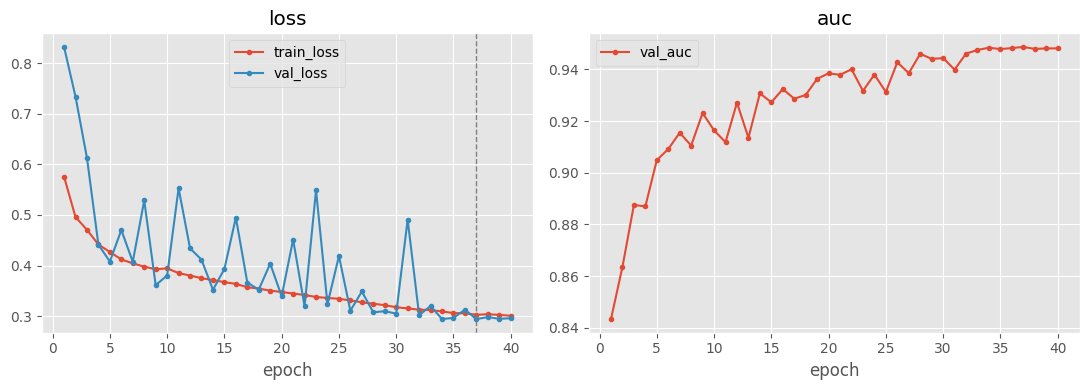

In [6]:
V.plot_training_curves(history).savefig(dirs["figures"] / "training_curves.png", dpi=150, bbox_inches="tight"); plt.show()

## 5 - In-distribution evaluation

tuned threshold: 0.4238


,threshold,n,n_fake,n_real,accuracy,f1_macro,precision,recall,auc_roc,pr_auc,mcc,brier
0,0.5,11963,5977,5986,0.882387,0.882375,0.889666,0.872846,0.951785,0.948596,0.764908,0.085489


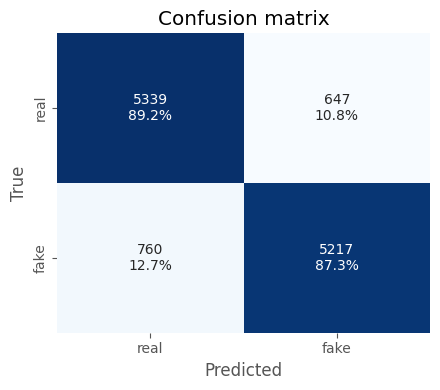

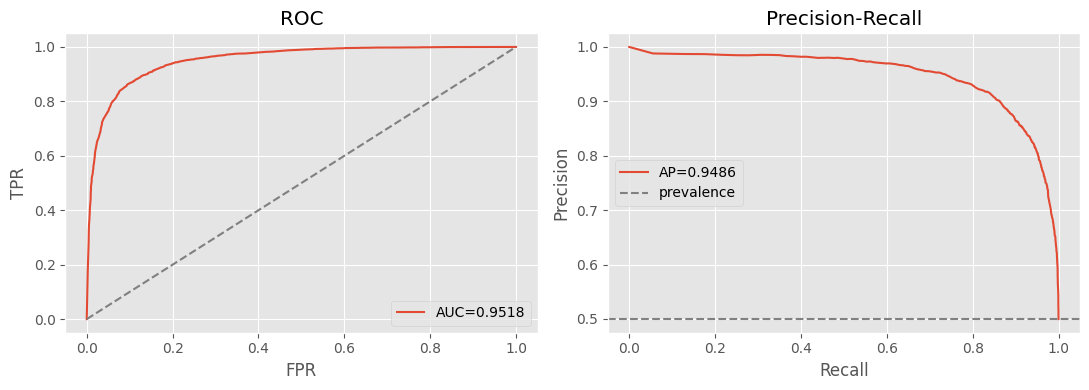

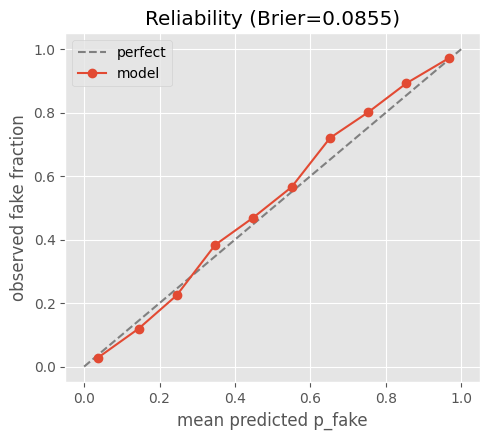

In [7]:
T.load_checkpoint(ckpt_path, model, map_location=device)
yt, pt, _ = T.evaluate(model, test_loader, device)
yv, pv, _ = T.evaluate(model, val_loader, device)
tuned = Me.best_f1_threshold(yv, pv)
m05 = Me.classification_metrics(yt, pt, threshold=0.5)
mtuned = Me.classification_metrics(yt, pt, threshold=tuned["threshold"])
print("tuned threshold:", round(tuned["threshold"], 4)); display(Me.summary_table(m05))
V.plot_confusion(m05["confusion_matrix"]).savefig(dirs["figures"] / "confusion.png", dpi=150, bbox_inches="tight")
V.plot_roc_pr(yt, pt).savefig(dirs["figures"] / "roc_pr.png", dpi=150, bbox_inches="tight")
V.plot_reliability(yt, pt).savefig(dirs["figures"] / "reliability.png", dpi=150, bbox_inches="tight"); plt.show()

## 6 - Cross-generator (OOD) preview

,generator,accuracy,n
0,adm,0.519400,5000
1,biggan,0.431800,5000
2,glide,0.527200,5000
3,midjourney,0.677936,4999
4,sdv5,0.541108,4999
5,vqdm,0.370000,5000
6,wukong,0.594400,5000


overall OOD accuracy: 0.5231  (in-dist 0.8824)


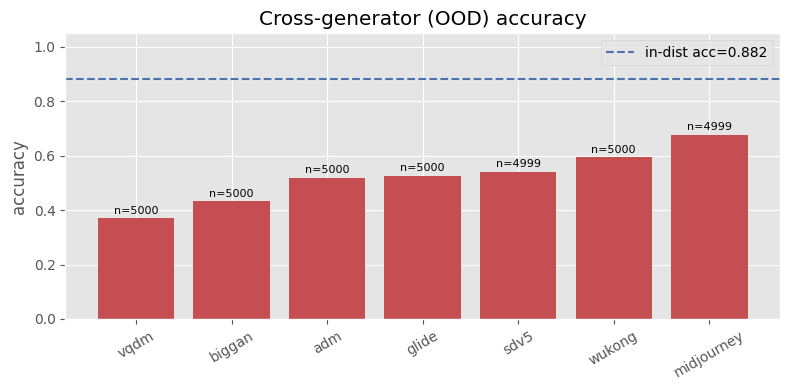

In [8]:
GEN_MAP = {
    "imagenet_ai_0419_biggan": "biggan", "imagenet_ai_0419_vqdm": "vqdm",
    "imagenet_ai_0424_sdv5": "sdv5", "imagenet_ai_0424_wukong": "wukong",
    "imagenet_ai_0508_adm": "adm", "imagenet_glide": "glide", "imagenet_midjourney": "midjourney",
}
ood_loader, ood_df = D.make_ood_loader(TINY_MANIFEST, WORKING_SIZE, BATCH_SIZE, mean, std, num_workers=NUM_WORKERS)
yo, po, _ = T.evaluate(model, ood_loader, device)
ood_df = ood_df.assign(p_fake=po, y_true=yo)
ood_df["y_pred"] = (ood_df["p_fake"] >= 0.5).astype(int)
ood_df["generator"] = ood_df["source"].map(GEN_MAP).fillna(ood_df["source"])
per_gen = pd.DataFrame([{"generator": g, "accuracy": float((d["y_pred"] == d["y_true"]).mean()), "n": int(len(d))} for g, d in ood_df.groupby("generator")])
overall_ood = float((ood_df["y_pred"] == ood_df["y_true"]).mean())
display(per_gen); print(f"overall OOD accuracy: {overall_ood:.4f}  (in-dist {m05['accuracy']:.4f})")
V.plot_per_generator_bar(per_gen, ref_acc=m05["accuracy"]).savefig(dirs["figures"] / "ood_per_generator.png", dpi=150, bbox_inches="tight"); plt.show()

## 7 - Explainability (Grad-CAM + residual maps)

C:\Users\user\AppData\Local\Temp\ipykernel_33044\1152262260.py:6: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_numpy.cpp:212.)
  arr = eda.read_rgb(ex["filepath"]); xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1)); x = xt.unsqueeze(0).to(device)


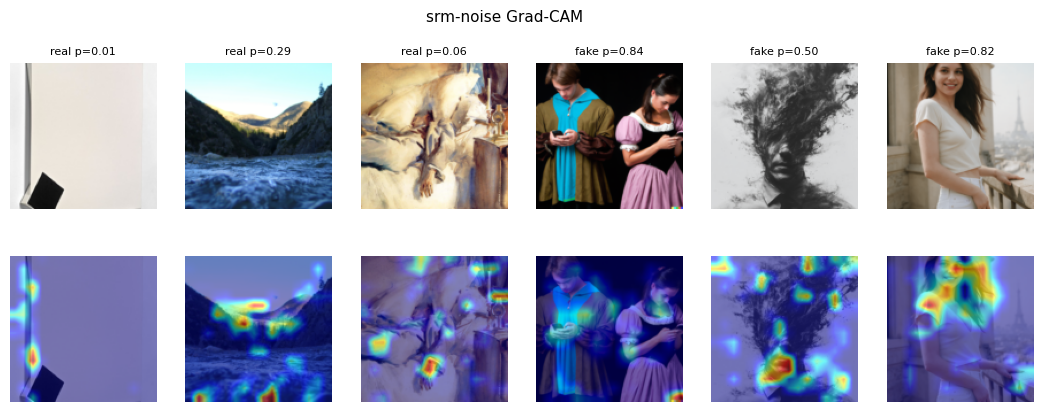

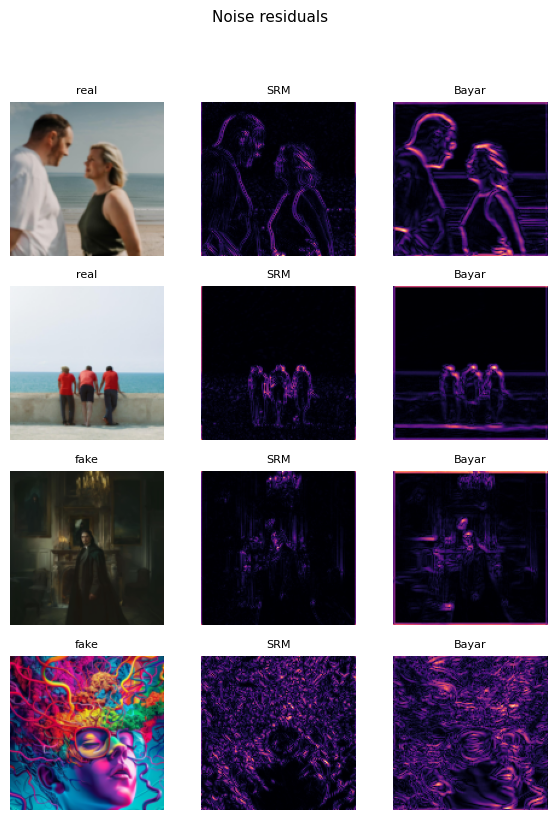

In [9]:
eval_tf = D.build_eval_tf(WORKING_SIZE, mean, std)
target_layers = [model.body.features[-1]]
examples = E.pick_examples(test_df, n_per_class=3, seed=0)
fig, axes = plt.subplots(2, len(examples), figsize=(2.2 * len(examples), 4.6)); model.eval()
for j, ex in enumerate(examples):
    arr = eda.read_rgb(ex["filepath"]); xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1)); x = xt.unsqueeze(0).to(device)
    rgb = D.denormalize(xt, mean, std).permute(1, 2, 0).numpy()
    with torch.no_grad():
        p = torch.sigmoid(model(x)).item()
    overlay = E.gradcam_overlay(model, target_layers, x, rgb)
    axes[0, j].imshow(rgb); axes[0, j].axis("off"); axes[0, j].set_title(f"{ex['label']} p={p:.2f}", fontsize=8)
    axes[1, j].imshow(overlay); axes[1, j].axis("off")
fig.suptitle("srm-noise Grad-CAM", fontsize=11)
fig.savefig(dirs["figures"] / "gradcam.png", dpi=150, bbox_inches="tight"); plt.show()

ex2 = E.pick_examples(test_df, n_per_class=2, seed=1)
fig2, ax2 = plt.subplots(len(ex2), 3, figsize=(7, 2.3 * len(ex2)))
for i, ex in enumerate(ex2):
    arr = eda.read_rgb(ex["filepath"]); xt = eval_tf(torch.from_numpy(arr).permute(2, 0, 1)); x = xt.unsqueeze(0).to(device)
    with torch.no_grad():
        res = model.residual(x)[0].cpu()
    rgb = D.denormalize(xt, mean, std).permute(1, 2, 0).numpy()
    ax2[i, 0].imshow(rgb); ax2[i, 0].set_title(ex["label"], fontsize=8); ax2[i, 0].axis("off")
    ax2[i, 1].imshow(res[:3].abs().mean(0), cmap="magma"); ax2[i, 1].set_title("SRM", fontsize=8); ax2[i, 1].axis("off")
    ax2[i, 2].imshow(res[3:].abs().mean(0), cmap="magma"); ax2[i, 2].set_title("Bayar", fontsize=8); ax2[i, 2].axis("off")
fig2.suptitle("Noise residuals", fontsize=11); fig2.savefig(dirs["figures"] / "residuals.png", dpi=150, bbox_inches="tight"); plt.show()

## 8 - Save metrics.json

In [10]:
record = {
    "pipeline": PIPELINE, "created": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "working_size": WORKING_SIZE, "normalization": NORM,
    "dataset": {"in_distribution": "ai-real-images", "ood": "tiny-genimage"},
    "threshold_default": 0.5, "threshold_tuned": tuned["threshold"],
    "in_distribution": {"at_0.5": m05, "at_tuned": mtuned},
    "ood": {"overall_accuracy": overall_ood, "per_generator": {r.generator: {"accuracy": r.accuracy, "n": r.n} for r in per_gen.itertuples()}, "preview": True},
    "tuning": TUNE_SUMMARY,
    "figures": {k: f"figures/{k}.png" for k in ['training_curves', 'confusion', 'roc_pr', 'reliability', 'ood_per_generator', 'gradcam', 'residuals']},
}
Me.save_metrics(record, dirs["metrics"] / "metrics.json")
print("saved", dirs["metrics"] / "metrics.json")

saved C:\Users\user\Desktop\MSc - AI\Εξάμηνο 2ο\Βαθιά Μάθηση\deepfake-detection\notebooks\artifacts\srm-noise\metrics\metrics.json
